# 1. Import Libraries

In [4]:
import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# 2. Data inspection

In [5]:
data = pd.read_csv('training_data.csv', index_col=0)
display(data.head(2))

,ID,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,78830894-cdd8-43d1-9655-03db74141b7a,Female,80.0,0,1,never,25.19,6.6,140,0
1,32262c0e-903a-46b8-9061-b1a2f5a3e9b2,Female,54.0,0,0,No Info,27.32,6.6,80,0


In [6]:
print(f'Dataset shape: {data.shape}')
print(f'Missing values:\n{data.isnull().sum()}')
print(f'\nClass distribution:')
print(data['diabetes'].value_counts())

Dataset shape: (73718, 10)
Missing values:
ID                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Class distribution:
diabetes
0    67168
1     6550
Name: count, dtype: int64


# 3. Data Preparation

In [7]:
# ID column dropped, ID has no predictive value
X = data.drop(['diabetes', 'ID'], axis=1)
y = data['diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

categorical_features = ['gender', 'smoking_history']
numeric_features    = ['age', 'bmi', 'hypertension', 'heart_disease',
                        'HbA1c_level', 'blood_glucose_level']

# handle_unknown='ignore', handles unseen categories in test data
prep = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# 4. Model training

In [8]:
# Compute class weight to handle imbalance
neg_count = (y == 0).sum()
pos_count = (y == 1).sum()
class_weight_ratio = neg_count / pos_count
print(f'scale_pos_weight = {class_weight_ratio:.2f}')

model = Pipeline(steps=[
    ('preprocessor', prep),
    ('classifier', XGBClassifier(
        random_state=42,
        scale_pos_weight=class_weight_ratio,  # handles class imbalance
        eval_metric='logloss'
    ))
])

model.fit(X_train, y_train)

scale_pos_weight = 10.25


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'hypertension',
                                                   'heart_disease',
                                                   'HbA1c_level',
                                                   'blood_glucose_level']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender',
                                                   'smoking_history'])])),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsam...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

# 5. Evaluation

In [9]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}\n')
print(classification_report(y_test, y_pred))

Accuracy: 0.92

              precision    recall  f1-score   support

           0       0.99      0.92      0.95     13491
           1       0.52      0.87      0.65      1253

    accuracy                           0.92     14744
   macro avg       0.75      0.90      0.80     14744
weighted avg       0.95      0.92      0.93     14744



In [10]:
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(f'Cross-Validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Cross-Validation Accuracy: 0.9226 ± 0.0031


# 6. Predict on test data and save submission

In [11]:
df_test = pd.read_csv('test_data.csv', index_col=0)
display(df_test.head())

,ID,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
0,ba0d6256-ca6e-46a7-a2fb-2518a8937fd7,Female,60.0,1,0,former,23.77,4.8,130
1,7102b1ab-c7a4-4a43-b1fc-cb588d0553b8,Male,2.0,0,0,No Info,15.19,5.0,159
2,51ba207e-4934-41b4-a31c-cd275c5ca555,Female,74.0,0,0,not current,39.59,6.5,160
3,7e17faaa-0402-4728-9719-83982eba3afd,Female,51.0,0,0,never,26.67,6.6,80
4,08b4e515-286e-4393-9a55-138962f9546e,Male,35.0,0,0,never,26.09,3.5,159


In [12]:
X_new = df_test.drop('ID', axis=1)
predictions = model.predict(X_new)

predicted_data = pd.DataFrame({'ID': df_test['ID'], 'prediction': predictions})
predicted_data.to_csv('predictions.csv', index=False)

print(f'Saved {len(predicted_data)} predictions')
print(predicted_data['prediction'].value_counts())
display(predicted_data.head())

Saved 26146 predictions
prediction
0    22358
1     3788
Name: count, dtype: int64


,ID,prediction
0,ba0d6256-ca6e-46a7-a2fb-2518a8937fd7,0
1,7102b1ab-c7a4-4a43-b1fc-cb588d0553b8,0
2,51ba207e-4934-41b4-a31c-cd275c5ca555,1
3,7e17faaa-0402-4728-9719-83982eba3afd,0
4,08b4e515-286e-4393-9a55-138962f9546e,0


# 7. Data Visualization

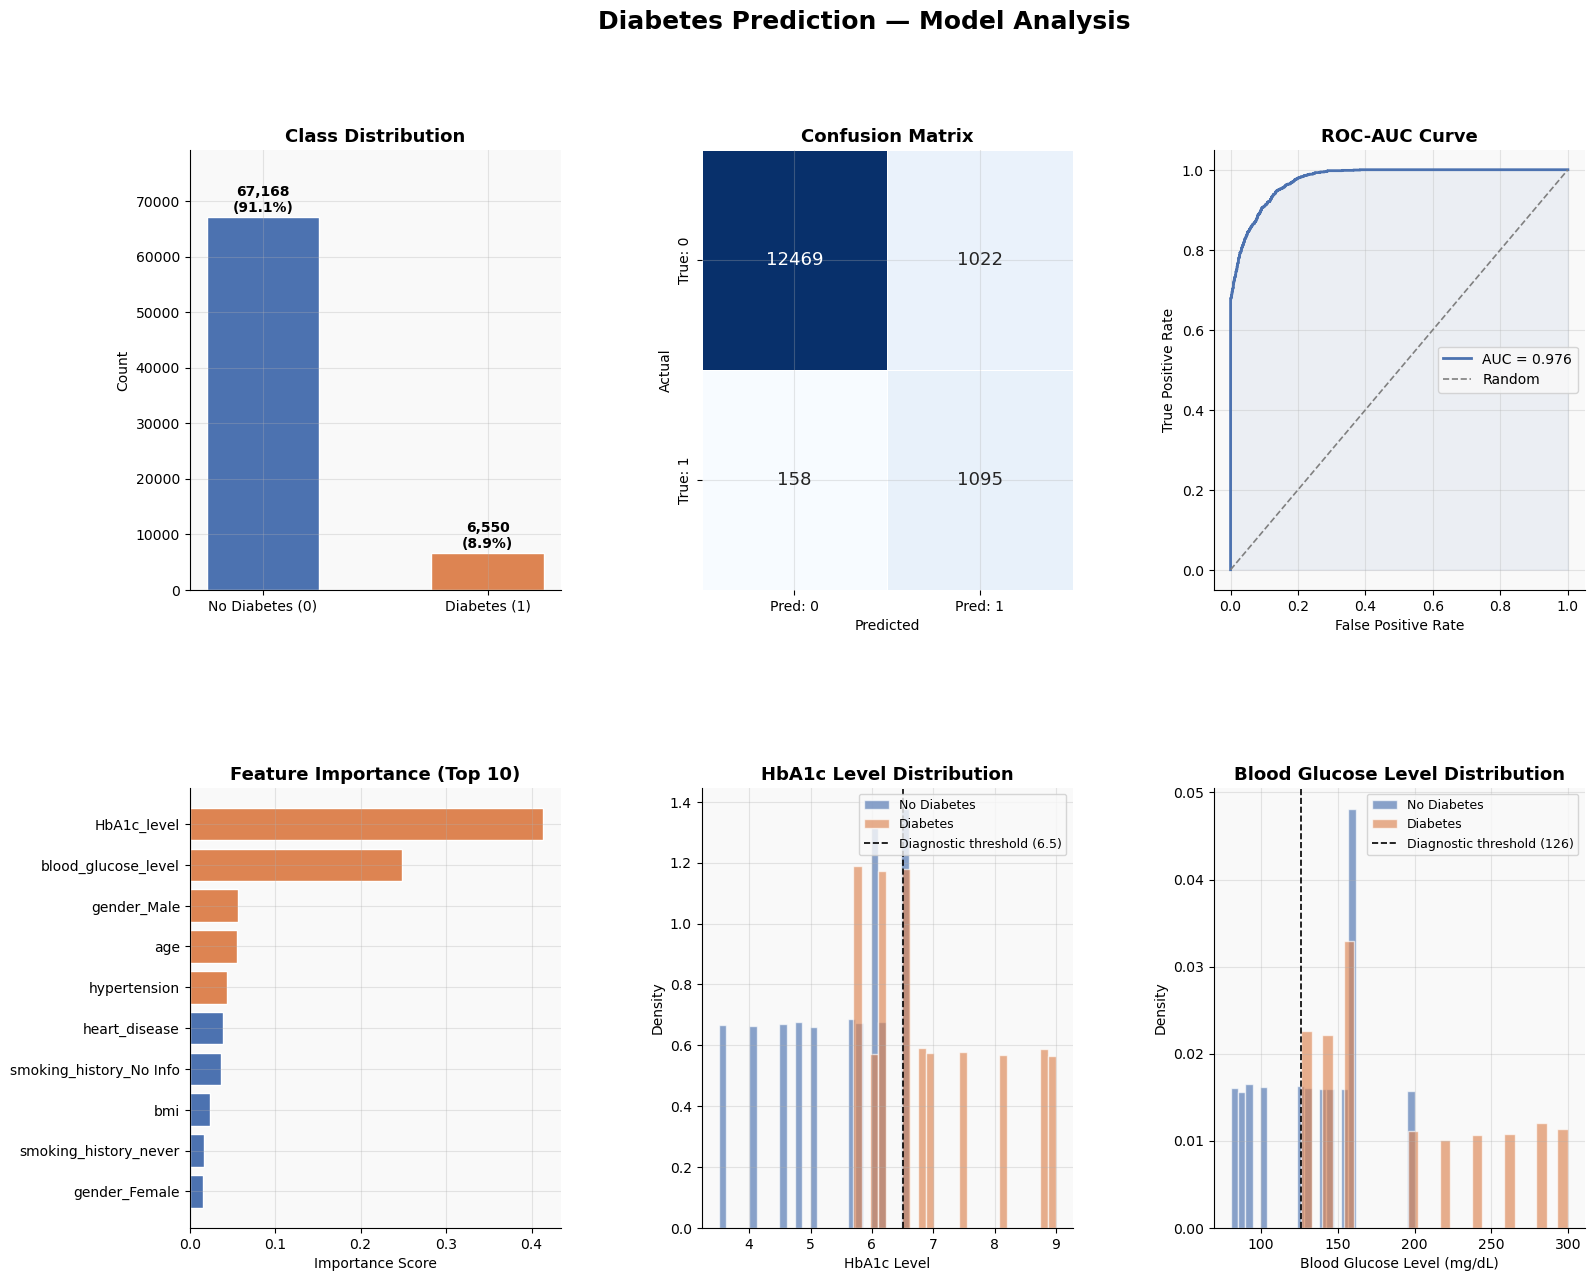

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f9',
})
BLUE ='#4C72B0'
RED  = '#DD8452'
PALETTE = [BLUE, RED]

y_prob = model.predict_proba(X_test)[:, 1]
xgb_model = model.named_steps['classifier']
cat_encoder = model.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features).tolist()
all_feature_names = numeric_features + cat_feature_names

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Diabetes Prediction — Model Analysis', fontsize=18, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# 1. Class Distribution
ax1 = fig.add_subplot(gs[0, 0])
counts = y.value_counts().sort_index()
bars = ax1.bar(['No Diabetes (0)', 'Diabetes (1)'], counts.values, color=PALETTE, width=0.5, edgecolor='white')
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 400,
             f'{val:,}\n({val/len(y)*100:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_title('Class Distribution', fontsize=13, fontweight='bold')
ax1.set_ylabel('Count')
ax1.set_ylim(0, counts.max() * 1.18)

# 2. Confusion Matrix
ax2 = fig.add_subplot(gs[0, 1])
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Pred: 0', 'Pred: 1'],
            yticklabels=['True: 0', 'True: 1'],
            linewidths=0.5, cbar=False, annot_kws={'size': 13})
ax2.set_title('Confusion Matrix', fontsize=13, fontweight='bold')
ax2.set_ylabel('Actual'); ax2.set_xlabel('Predicted')

# 3. ROC Curve
ax3 = fig.add_subplot(gs[0, 2])
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
ax3.plot(fpr, tpr, color=BLUE, lw=2, label=f'AUC = {roc_auc:.3f}')
ax3.plot([0, 1], [0, 1], color='gray', lw=1.2, linestyle='--', label='Random')
ax3.fill_between(fpr, tpr, alpha=0.08, color=BLUE)
ax3.set_title('ROC-AUC Curve', fontsize=13, fontweight='bold')
ax3.set_xlabel('False Positive Rate'); ax3.set_ylabel('True Positive Rate')
ax3.legend(fontsize=10)

# 4. Feature Importance
ax4 = fig.add_subplot(gs[1, 0])
feat_df = pd.DataFrame({'feature': all_feature_names, 'importance': xgb_model.feature_importances_})
feat_df = feat_df.sort_values('importance', ascending=True).tail(10)
colors = [RED if v > feat_df['importance'].median() else BLUE for v in feat_df['importance']]
ax4.barh(feat_df['feature'], feat_df['importance'], color=colors, edgecolor='white')
ax4.set_title('Feature Importance (Top 10)', fontsize=13, fontweight='bold')
ax4.set_xlabel('Importance Score')

# 5. HbA1c Distribution
ax5 = fig.add_subplot(gs[1, 1])
for cls, color, label in zip([0, 1], PALETTE, ['No Diabetes', 'Diabetes']):
    ax5.hist(data[data['diabetes'] == cls]['HbA1c_level'],
             bins=25, alpha=0.65, color=color, label=label, edgecolor='white', density=True)
ax5.axvline(6.5, color='black', linestyle='--', linewidth=1.2, label='Diagnostic threshold (6.5)')
ax5.set_title('HbA1c Level Distribution', fontsize=13, fontweight='bold')
ax5.set_xlabel('HbA1c Level'); ax5.set_ylabel('Density'); ax5.legend(fontsize=9)

# 6. Blood Glucose Distribution
ax6 = fig.add_subplot(gs[1, 2])
for cls, color, label in zip([0, 1], PALETTE, ['No Diabetes', 'Diabetes']):
    ax6.hist(data[data['diabetes'] == cls]['blood_glucose_level'],
             bins=25, alpha=0.65, color=color, label=label, edgecolor='white', density=True)
ax6.axvline(126, color='black', linestyle='--', linewidth=1.2, label='Diagnostic threshold (126)')
ax6.set_title('Blood Glucose Level Distribution', fontsize=13, fontweight='bold')
ax6.set_xlabel('Blood Glucose Level (mg/dL)'); ax6.set_ylabel('Density'); ax6.legend(fontsize=9)

plt.savefig('visualization.png', dpi=150, bbox_inches='tight')
plt.show()